# The escalated case: the report Anand signs, solution

**Week 2, Tuesday. The escalated case, solution twin.** Every placeholder is filled and
every check passes. Under each step, a line says why the other three letters fail. This file is a
learner file, so it prints no list and no total that the room is meant to find: each list, the Q2
bridge and the report by channel sit in an empty cell with the lines to type above it, and the
checks assert without printing numbers. Run the empty cells yourself and compare with your own.

> **The client asks.** "Booked revenue is not collected revenue. Some orders are paid in two
> instalments, some are refunded, some were never paid at all. Show me, order by order, what we
> actually collected against what we booked in Q2. If there is a gap, I want to know which orders
> and which channel."
>
> Anand Iyer, finance controller, Kalpa Retail

> **Kavya's review.** "Rows in, rows out, and the difference explained, written above the number.
> If the count does not close, the number does not leave the team."

The three rounds built every piece: order grain, the row count, the bridge, the anti-join and the
retry grain. The case puts them into one report by channel, with every payment row accounted for.

**Setup.** The next cell finds the helper by walking up from this folder and connects to the Kalpa
warehouse. Nothing here creates a table.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit
from decimal import Decimal

conn = kit.connect()
conn.autocommit = True


def run(query, params=None):
    """Run a query on this notebook's one connection and return its rows as dictionaries."""
    return kit.sql(query, params, conn=conn)


def show(rows, caption="", money=()):
    """Set the rows as the kit's table, with the named columns in Rs and NULL written out."""
    headers = list(rows[0]) if rows else ["result"]
    body = [["NULL" if r[h] is None else kit.rupees(r[h]) if h in money
             else int(r[h]) if isinstance(r[h], Decimal) and r[h] == r[h].to_integral_value() else r[h]
             for h in headers] for r in rows]
    kit.table(headers, body or [["no rows"]], caption)


def crore(v):
    """A chart label in crore, since eight-digit rupee labels do not fit under a column."""
    return f"{float(v) / 1e7:.2f}"


print("warehouse connected:", run("SELECT count(*) AS n FROM orders WHERE quarter = 'Q2'")[0]["n"], "Q2 orders")

warehouse connected: 462 Q2 orders


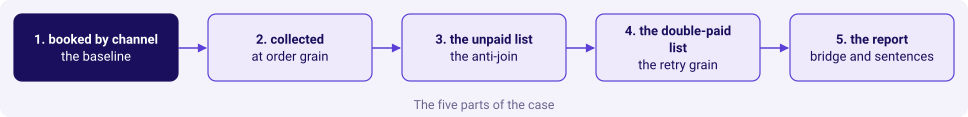

In [2]:
kit.flow(["1. booked by channel\nthe baseline", "2. collected\nat order grain",
          "3. the unpaid list\nthe anti-join", "4. the double-paid list\nthe retry grain",
          "5. the report\nbridge and sentences"], lit=0, title="The five parts of the case")

## Part 1. The baseline: booked by channel, from orders alone

Every later number is reconciled to this one, so it comes from the orders table with no join, over
every Q2 order whatever its status, which is Week 1's definition of booked.

channel,orders_in,booked
app,153,"Rs 4,25,90,270"
store,159,"Rs 3,21,48,730"
web,150,"Rs 2,36,61,000"


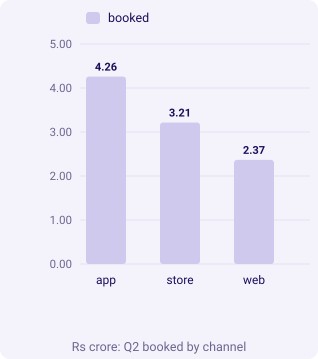

In [3]:
# TODO 1. Which rows give the baseline that booked is reconciled to?
#   a) orders joined to payments, Q2 only
#   b) orders with status delivered, Q2 only
#   c) orders alone, Q2 only, every status
#   d) orders left-joined to payments, Q2 only, every status
options_1 = {
    "a": "orders o JOIN payments p ON p.order_id = o.order_id WHERE o.quarter = 'Q2'",
    "b": "orders o WHERE o.quarter = 'Q2' AND o.status = 'delivered'",
    "c": "orders o WHERE o.quarter = 'Q2'",
    "d": "orders o LEFT JOIN payments p ON p.order_id = o.order_id WHERE o.quarter = 'Q2'",
}
choice_1 = "c"

baseline = run(f"""
SELECT o.channel, count(*) AS orders_in, sum(o.amount) AS booked
FROM {options_1[choice_1]}
GROUP BY o.channel
ORDER BY o.channel
""")
show(baseline, "Part 1: Q2 orders and booked by channel", money=["booked"])
kit.columns([r["channel"] for r in baseline], [("booked", [float(r["booked"]) for r in baseline])],
            fmt=crore, title="Rs crore: Q2 booked by channel")

**Why c.** Option a counts each order once per payment row and drops the unpaid ones, option b drops the returned and cancelled orders that Week 1 counted as booked, and option d fans out on the two-instalment orders, so only c reproduces Monday's Rs 9,84,00,000.

In [4]:
orders_in = sum(r["orders_in"] for r in baseline)
booked = sum(r["booked"] for r in baseline)
kit.check("the baseline holds all 462 Q2 orders", orders_in == 462, f"{orders_in} orders")
kit.check("booked is Monday's Rs 9,84,00,000", booked == 98400000, kit.rupees(booked))
kit.check("three channels, app, store and web", [r["channel"] for r in baseline] == ["app", "store", "web"])

## Part 2. Collected by channel, at order grain, with the count reconciliation

Payments are brought to one row per order in a CTE and then joined to the Q2 orders. Decide what a
retry is before you trust the CTE: the feed can post one instalment twice.

The reconciliation, written before the cell runs:

- Rows in, from part 1: 462 Q2 orders.
- Rows out, from this query: 462, one per order, because payments reach one row per order before the join.
- The difference, and why: none; a difference would mean the join multiplied or dropped orders.

In [5]:
# TODO 2. What grain should the payments CTE have before it meets the orders?
#   a) sum every payment row per order, as the feed posted it
#   b) count each instalment once, then sum the instalments per order
#   c) no CTE grain: one row per payment, joined straight to orders
#   d) keep only the earliest payment row of each order, then sum per order
options_2 = {
    "a": "SELECT order_id, sum(amount) AS collected FROM payments GROUP BY order_id",
    "b": "SELECT order_id, sum(amount) AS collected FROM (SELECT order_id, instalment_no, max(amount) AS amount "
         "FROM payments GROUP BY order_id, instalment_no) i GROUP BY order_id",
    "c": "SELECT order_id, amount AS collected FROM payments",
    "d": "SELECT order_id, sum(amount) AS collected FROM payments WHERE payment_id IN "
         "(SELECT min(payment_id) FROM payments GROUP BY order_id) GROUP BY order_id",
}
choice_2 = "b"
# TODO 3. Which join attaches the per-order payments to the Q2 orders?
#   a) JOIN: keep the orders that found a payment
#   b) RIGHT JOIN: keep every payment, matched or not
#   c) FULL JOIN: keep orphans from both sides
#   d) LEFT JOIN: keep every Q2 order, paid or not
options_3 = {
    "a": "JOIN",
    "b": "RIGHT JOIN",
    "c": "FULL JOIN",
    "d": "LEFT JOIN",
}
choice_3 = "d"
# TODO 4. Which expression is collected, in rupees, for a channel?
#   a) sum the per-order amount, with a missing payment as zero
#   b) sum the booked value of every order that has a payment
#   c) sum the per-order amount, with a missing payment as fully paid
#   d) count the orders whose per-order amount is present
options_4 = {
    "a": "sum(coalesce(po.collected, 0))",
    "b": "sum(o.amount) FILTER (WHERE po.order_id IS NOT NULL)",
    "c": "sum(coalesce(po.collected, o.amount))",
    "d": "count(po.collected)",
}
choice_4 = "a"

part2 = run(f"""
WITH per_order AS ({options_2[choice_2]})
SELECT o.channel, count(*) AS rows_out, sum(o.amount) AS booked,
       {options_4[choice_4]} AS collected
FROM orders o
{options_3[choice_3]} per_order po ON po.order_id = o.order_id
WHERE o.quarter = 'Q2'
GROUP BY o.channel
ORDER BY o.channel
""")
show([{k: r[k] for k in ("channel", "rows_out", "booked")} for r in part2],
     "Part 2: rows out and booked after the join, by channel", money=["booked"])

channel,rows_out,booked
app,153,"Rs 4,25,90,270"
store,159,"Rs 3,21,48,730"
web,150,"Rs 2,36,61,000"


**Why b.** Option a keeps the gateway's second posting inside collected, option c brings back round 1's fan-out, and option d throws away every second instalment, so only b counts each instalment once and every instalment once.

**Why d.** Option a removes the unpaid orders from booked, option b keeps payments and filters orders after, which behaves as a plain JOIN here, and option c adds payments with no order to the report, so only d keeps every Q2 order exactly once.

**Why a.** Option b is round 1's value of the paid orders, option c books every unpaid order as collected and hides the gap, and option d counts orders instead of rupees, so only a is collected in rupees with the unpaid orders at zero.

In [6]:
feed = {r["channel"]: r["posted"] for r in run("""
SELECT o.channel, sum(p.amount) AS posted FROM payments p JOIN orders o ON o.order_id = p.order_id
WHERE o.quarter = 'Q2' GROUP BY o.channel""")}
rows_out = sum(r["rows_out"] for r in part2)
collected = sum(r["collected"] for r in part2)
kit.check("rows out equal rows in", rows_out == orders_in, f"{rows_out} rows out, {orders_in} in")
kit.check("booked after the join equals booked from part 1", sum(r["booked"] for r in part2) == booked)
kit.check("collected sits below booked in every channel", all(r["collected"] < r["booked"] for r in part2))
kit.check("collected sits below what the feed posted, so a retry was taken out",
          all(r["collected"] < feed[r["channel"]] for r in part2))

**Your turn.** Read collected by channel. Type these lines into the empty cell below and run them.

```python
show(part2, "Part 2: booked and collected by channel", money=["booked", "collected"])
kit.columns([r["channel"] for r in part2],
            [("booked", [float(r["booked"]) for r in part2]),
             ("collected", [float(r["collected"]) for r in part2])],
            fmt=crore, title="Rs crore: booked and collected by channel, Q2")
```

## Part 3. The unpaid list: every Q2 order with no payment

Anand asked which orders and which channel. The anti-join keeps the orders the LEFT JOIN could not
match, and the list's booked value must equal booked minus collected from part 2.

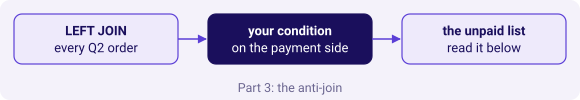

In [7]:
# TODO 5. After LEFT JOIN payments p, which condition keeps only the unpaid orders?
#   a) the payment amount is zero
#   b) the order was not delivered
#   c) no payment row matched the order
#   d) the payment landed after the quarter closed
options_5 = {
    "a": "p.amount = 0",
    "b": "o.status <> 'delivered'",
    "c": "p.payment_id IS NULL",
    "d": "p.paid_date > '2026-09-30'",
}
choice_5 = "c"

unpaid = run(f"""
SELECT o.order_id, o.channel, o.status, o.amount AS booked
FROM orders o
LEFT JOIN payments p ON p.order_id = o.order_id
WHERE o.quarter = 'Q2' AND {options_5[choice_5]}
ORDER BY o.channel, o.amount DESC, o.order_id
""")
kit.flow(["LEFT JOIN\nevery Q2 order", "your condition\non the payment side", "the unpaid list\nread it below"],
         lit=1, title="Part 3: the anti-join")

**Why c.** Option a finds nothing, because an unpaid order has no payment row with any amount, option b tests delivery, which says nothing about money, and option d filters on a date that is NULL for the unpaid orders, so only c is the anti-join.

In [8]:
_ne = {r["order_id"] for r in run("""SELECT o.order_id FROM orders o WHERE o.quarter = 'Q2'
    AND NOT EXISTS (SELECT 1 FROM payments p WHERE p.order_id = o.order_id)""")}
kit.check("the unpaid list matches NOT EXISTS, order for order", {r["order_id"] for r in unpaid} == _ne and len(_ne) > 0)
kit.check("the unpaid list's booked value equals booked minus collected",
          sum(r["booked"] for r in unpaid) == booked - collected)

**Your turn.** Read the count first and the rows second. Type these lines into the empty cell below and run them.

```python
print(len(unpaid), "Q2 orders with no payment")
show(unpaid, "Part 3: the unpaid list", money=["booked"])
```

## Part 4. The double-paid list: the same instalment posted more than once

A retry is one intended payment that the gateway posted again. Two payment rows on one order are
often two instalments paid as invoiced, and those must stay off this list.

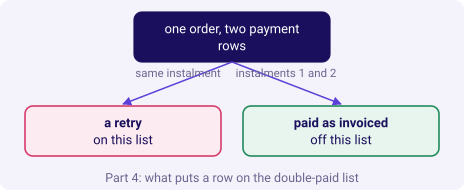

In [9]:
# TODO 6. What is the grain of the GROUP BY that finds a gateway retry?
#   a) the order
#   b) the order and the instalment
#   c) the order and the day it was paid
#   d) the payment row itself
options_6 = {
    "a": "p.order_id",
    "b": "p.order_id, p.instalment_no",
    "c": "p.order_id, p.paid_date",
    "d": "p.payment_id",
}
choice_6 = "b"
# TODO 7. Which HAVING condition keeps the payments posted more than once?
#   a) more than one row in the group
#   b) more than one distinct instalment in the group
#   c) at least one row in the group
#   d) a group total above Rs 1,000
options_7 = {
    "a": "count(*) > 1",
    "b": "count(DISTINCT p.instalment_no) > 1",
    "c": "count(*) >= 1",
    "d": "sum(p.amount) > 1000",
}
choice_7 = "a"

retries = run(f"""
SELECT p.order_id, o.channel, p.instalment_no, count(*) AS times_posted,
       max(p.amount) AS amount, max(p.amount) * (count(*) - 1) AS surplus
FROM payments p
JOIN orders o ON o.order_id = p.order_id
WHERE o.quarter = 'Q2'
GROUP BY {options_6[choice_6]}, o.channel, p.instalment_no
HAVING {options_7[choice_7]}
ORDER BY o.channel, p.order_id
""")
kit.tree({"label": "one order, two payment rows", "kind": "lit", "branches": [
    ("same instalment", {"label": "a retry\non this list", "kind": "bad"}),
    ("instalments 1 and 2", {"label": "paid as invoiced\noff this list", "kind": "good"})]},
    taken=["same instalment"], title="Part 4: what puts a row on the double-paid list")

**Why b.** Option a is the naive list that calls every instalment a double, option c misses a retry posted the next day and can flag two instalments paid on one day, and option d groups each row with itself, so only b is the grain of one intended payment.

**Why a.** Option b finds the orders paid in instalments, the opposite of a retry, option c lists every instalment, and option d is a size filter that says nothing about repetition, so only a keeps the instalments posted more than once.

In [10]:
posted = sum(feed.values())
_naive = {r["order_id"] for r in run("""SELECT p.order_id FROM payments p JOIN orders o ON o.order_id = p.order_id
    WHERE o.quarter = 'Q2' GROUP BY p.order_id HAVING count(*) > 1""")}
kit.check("the double-paid list is far shorter than the orders with two payment rows",
          0 < len({r["order_id"] for r in retries}) < len(_naive) / 4)
kit.check("the list's surplus equals what the feed posted minus collected", sum(r["surplus"] for r in retries) == posted - collected)
kit.check("every retry on the list repeats one instalment", all(r["times_posted"] > 1 for r in retries))

**Your turn.** Read the count, the channels and the amounts. Type these lines into the empty cell below and run them.

```python
print(len(retries), "Q2 instalments posted more than once")
show(retries, "Part 4: the double-paid list", money=["amount", "surplus"])
```

## Part 5. The report by channel, the bridge, and every payment row accounted for

The report carries booked, collected, the gap, the unpaid list's count and value, and the surplus
posted twice, by channel. The invariant is checked in every channel, the bridge is closed from
booked to what the feed posted, and every payment row in the feed is placed: on a Q1 order, on a Q2
order, or on no order at all.

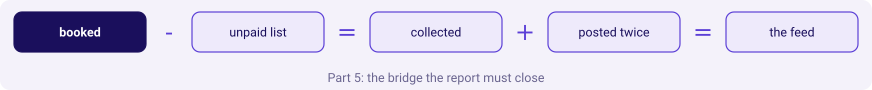

In [11]:
# TODO 8. Which invariant must hold in every channel before the report is signed?
#   a) booked equals collected in every channel
#   b) booked minus what the feed posted equals the unpaid value
#   c) collected equals what the feed posted
#   d) booked minus collected equals the unpaid value
options_8 = {
    "a": lambda r: r["booked"] == r["collected"],
    "b": lambda r: r["booked"] - r["posted"] == r["unpaid_booked"],
    "c": lambda r: r["collected"] == r["posted"],
    "d": lambda r: r["booked"] - r["collected"] == r["unpaid_booked"],
}
choice_8 = "d"
# TODO 9. What does the bridge add to collected to land on what the feed posted?
#   a) the unpaid list's booked value
#   b) the orphan payments' total
#   c) the surplus on the double-paid list
#   d) the booked value of the orders with two payment rows
options_9 = {
    "a": "unpaid",
    "b": "orphans",
    "c": "surplus",
    "d": "naive",
}
choice_9 = "c"
# TODO 10. Which FROM clause finds the payments that no order can claim?
#   a) orders left-joined to payments, keeping the orders that have no payment
#   b) payments joined to orders, keeping the matched rows
#   c) payments whose order is not a Q2 order
#   d) payments left-joined to orders, keeping payments with no order
options_10 = {
    "a": "orders o LEFT JOIN payments p ON p.order_id = o.order_id WHERE p.payment_id IS NULL",
    "b": "payments p JOIN orders o ON o.order_id = p.order_id",
    "c": "payments p WHERE p.order_id NOT IN (SELECT order_id FROM orders WHERE quarter = 'Q2')",
    "d": "payments p LEFT JOIN orders o ON o.order_id = p.order_id WHERE o.order_id IS NULL",
}
choice_10 = "d"

report = []
for r in part2:
    ch = r["channel"]
    report.append({"channel": ch, "orders": r["rows_out"], "booked": r["booked"], "collected": r["collected"],
                   "gap": r["booked"] - r["collected"],
                   "unpaid_orders": sum(1 for u in unpaid if u["channel"] == ch),
                   "unpaid_booked": sum((u["booked"] for u in unpaid if u["channel"] == ch), Decimal(0)),
                   "posted_twice": sum((d["surplus"] for d in retries if d["channel"] == ch), Decimal(0)),
                   "posted": feed[ch]})
invariant = options_8[choice_8]

orphans = run(f"""
SELECT p.payment_id, p.order_id, p.paid_date, p.amount
FROM {options_10[choice_10]}
ORDER BY p.payment_id
""")
moves = {"unpaid": sum(r["unpaid_booked"] for r in report), "surplus": sum(r["posted_twice"] for r in report),
         "orphans": sum((o["amount"] or 0 for o in orphans), Decimal(0)),
         "naive": run("""SELECT sum(amount) AS s FROM orders WHERE quarter = 'Q2' AND order_id IN
                         (SELECT order_id FROM payments GROUP BY order_id HAVING count(*) > 1)""")[0]["s"]}
second_move = moves[options_9[choice_9]]
kit.equation(["booked", "-", "unpaid list", "=", "collected", "+", "posted twice", "=", "the feed"],
             title="Part 5: the bridge the report must close")

**Why d.** Option a would only hold if nothing were unpaid, option b mixes the retries into the gap, and option c would only hold if the feed never double-posted, so only d ties the gap to the unpaid list.

**Why c.** Option a is the first move, which runs from booked to collected, option b belongs to no Q2 order, and option d is the naive list's value, so only c lands collected on what the feed posted.

**Why d.** Option a lists unpaid orders, which are part 3, option b is every matched payment, and option c also catches every payment on a Q1 order, so only d finds the payments no order can claim.

In [12]:
matched = run("""SELECT coalesce(o.quarter, 'none') AS q, count(*) AS n FROM payments p
                 LEFT JOIN orders o ON o.order_id = p.order_id GROUP BY 1""")
matched = {r["q"]: r["n"] for r in matched}
feed_rows = run("SELECT count(*) AS n FROM payments")[0]["n"]
kit.check("the invariant holds in every channel", all(invariant(r) for r in report))
kit.check("the bridge's first move lands booked on collected", booked - moves["unpaid"] == collected)
kit.check("the bridge's second move lands collected on what the feed posted", collected + second_move == posted)
kit.check("every payment row sits on a Q1 order, a Q2 order or no order",
          matched.get("Q1", 0) + matched.get("Q2", 0) + len([o for o in orphans if o["payment_id"]]) == feed_rows)
kit.check("the orphan payments are found and match no order",
          len(orphans) > 0 and all(o["payment_id"] and o["order_id"] for o in orphans))

**Your turn.** Print the report and the bridge row, account for every payment row, draw the bridge and the per-channel chart, and list the payments no order can claim. Type these lines into the empty cell below and run them.

```python
show(report, "Part 5: the Q2 report by channel",
     money=["booked", "collected", "gap", "unpaid_booked", "posted_twice", "posted"])
show([{"booked": booked, "less_never_paid": -moves["unpaid"], "collected": collected,
       "plus_posted_twice": second_move, "posted_in_feed": posted}],
     "Part 5: the Q2 bridge in one row",
     money=["booked", "less_never_paid", "collected", "plus_posted_twice", "posted_in_feed"])
show([{"on a Q1 order": matched.get("Q1", 0), "on a Q2 order": matched.get("Q2", 0),
       "on no order": len(orphans), "rows in the feed": feed_rows}],
     "Part 5: every payment row accounted for")
kit.bridge(("booked", float(booked)),
           [("less never paid", -float(moves["unpaid"])), ("plus posted twice", float(second_move))],
           end_label="posted in the feed", lo=9.6e7, fmt=lambda v: f"{v / 1e5:,.2f}",
           title="Q2 in Rs lakh, axis from 960 lakh so the moves show; collected sits after the first move")
kit.columns([r["channel"] for r in report],
            [("booked", [float(r["booked"]) for r in report]),
             ("collected", [float(r["collected"]) for r in report])],
            fmt=crore, title="Rs crore: booked and collected by channel, Q2")
show(orphans, "Payments no order can claim, for the data platform lead", money=["amount"])
```

## The two sentences to Anand

The sentences carry the numbers your own cells printed; this file leaves them for you to fill. A
model shape: "Q2 booked Rs ____ and collected Rs ____; the gap of Rs ____ is exactly ____ orders
that were never paid, most of the value in ____, and the list by channel is attached. The feed
also posted ____ instalments twice, Rs ____ in all, which the refund desk will return, and ____
payments that match no order have gone to the data platform lead." Kavya checks that every number
in the two sentences ties to a check above that passed.

**The letters.** 1c 2b 3d 4a 5c 6b 7a 8d 9c 10d. Post your two sentences beside them.

In [13]:
kit.check_summary()
print("Next: Wednesday opens a new case on the joined table.")

Next: Wednesday opens a new case on the joined table.
